In [ ]:
from IPython.utils import io
import tqdm.notebook
import os, sys, random
total = 100
with tqdm.notebook.tqdm(total=total) as pbar:
    with io.capture_output() as captured:
      # Instalar rdkit
      !pip -q install rdkit
      pbar.update(100)

  0%|          | 0/100 [00:00<?, ?it/s]

In [ ]:
import pandas as pd
from rdkit import Chem, DataStructs
from rdkit.Chem import AllChem, Draw, PandasTools, Descriptors, Descriptors3D, rdMolDescriptors, Scaffolds
from rdkit.Chem.Scaffolds.MurckoScaffold import GetScaffoldForMol
PandasTools.RenderImagesInAllDataFrames(images = True) #
from rdkit.Chem.Draw import IPythonConsole
import numpy as np

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


##Compounds

In [ ]:
DB_1 = pd.read_csv("/content/drive/MyDrive/FBDD_Denovo_VRC/Caracterizacion_denovo/MolecularDescriptors_df_highdiv.csv")
DB_2 = pd.read_csv("/content/drive/MyDrive/FBDD_Denovo_VRC/Caracterizacion_denovo/MolecularDescriptors_df_druglike.csv")

DB_denovo = pd.concat([DB_1, DB_2], ignore_index=True)
DB_denovo

,ID_deNovo,SMILES,Name,InChI,Formula,MW,LogP,pKd,Structure,Synthesize,...,FractionOfChiralCarbons,NumHeavyAtoms,Ring,AliphaticRing,AromaticRing,Heterocycle,AliphaticHeterocycle,AromaticHeterocycle,SpiroAtom,BridgeheadAtom
0,HD8_HD001,OC(=S)NC1=CC=C(C(=C1)/C=C/CC1=NC(=CN1)[C@H](C)...,6/000000103,InChI=1S/C17H19N3OS2/c1-3-12-7-8-14(19-17(21)2...,C17H19N3OS2,345.096954,3.45,4.63,-11.50,24.70,...,0.058824,23,2,0,2,1,0,2,0,0
1,HD8_HD002,OC1=CC=C(C(=C1)C1=CC(Cl)=CC(=C1O)Cl)CC(=O)C,3/000000076,InChI=1S/C15H12Cl2O3/c1-8(18)4-9-2-3-11(19)7-1...,C15H12O3Cl2,310.016350,4.09,4.54,-6.86,15.00,...,0.000000,20,2,0,2,0,0,2,0,0
2,HD8_HD003,OC(=O)C/C=C/C1=CNC(=NC1)C1=C(Br)C=NN1,4/000000002,InChI=1S/C11H11BrN4O2/c12-8-6-15-16-10(8)11-13...,C11H11N4O2Br,310.006538,1.27,4.50,-2.49,23.90,...,0.000000,18,2,1,1,2,1,1,0,0
3,HD8_HD004,OC1=CC=C(C=C1)CC#CC1C(I)=CN=C(C=1Cl)N,3/000000134,InChI=1S/C14H10ClIN2O/c15-13-11(12(16)8-18-14(...,C14H10N2OClI,383.952639,4.38,4.48,-5.80,16.40,...,0.000000,19,2,0,2,1,0,2,0,0
4,HD8_HD005,OC1=CC=C(C=C1[C@H](CC1=CSN=C1)O)C(=C)C=C,3/000000315,InChI=1S/C15H15NO2S/c1-3-10(2)12-4-5-14(17)13(...,C15H15NO2S,273.082350,2.62,4.34,-5.32,19.10,...,0.066667,19,2,0,2,1,0,2,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
616,HD8_DL287,OC(=O)C1=NN=C(O1)CC#CC(O)(F)F,6/000000013,"InChI=1S/C7H4F2N2O4/c8-7(9,14)3-1-2-4-10-11-5(...",C7H4N2O4F2,218.013913,0.57,3.02,-5.31,24.20,...,0.000000,15,1,0,1,1,0,1,0,0
617,HD8_DL288,C(=C\CN)/C1=CC=C2C(=C1)C(=O)C=CN2,6/000000083,InChI=1S/C12H12N2O/c13-6-1-2-9-3-4-11-10(8-9)1...,C12H12N2O,200.094963,1.51,3.01,-9.66,3.58,...,0.000000,15,2,0,2,1,0,2,0,0
618,HD8_DL289,OC(=O)C/C=C/C1C=CC=C(C=1Cl)O,4/000000101,InChI=1S/C10H9ClO3/c11-10-7(3-1-5-8(10)12)4-2-...,C10H9O3Cl,212.024022,2.27,3.01,-2.70,2.22,...,0.000000,14,1,0,1,0,0,1,0,0
619,HD8_DL290,OC(=O)/C=C/CCC1=NC2=C(N1)N=CC=C2,4/000000122,InChI=1S/C11H11N3O2/c15-10(16)6-2-1-5-9-13-8-4...,C11H11N3O2,217.085127,1.00,3.01,-10.12,4.81,...,0.000000,16,2,0,2,2,0,2,0,0


In [ ]:
# Delete duplicates
DB_denovo = DB_denovo.drop_duplicates(subset=["SMILES_curated"], keep="first").reset_index(drop=True)
print(DB_denovo.shape)

(621, 36)


In [ ]:
# Selec columns
DB_denovo = DB_denovo[['ID_deNovo', 'Database', "SMILES_curated", "pKd"]]
DB_denovo

,ID_deNovo,Database,SMILES_curated,pKd
0,HD8_HD001,smHD8_HighDiv,C=Cc1ccc(NC(O)=S)cc1/C=C/Cc1nc([C@H](C)S)c[nH]1,4.63
1,HD8_HD002,smHD8_HighDiv,CC(=O)Cc1ccc(O)cc1-c1cc(Cl)cc(Cl)c1O,4.54
2,HD8_HD003,smHD8_HighDiv,O=C(O)C/C=C/C1=CNC(c2[nH]ncc2Br)=NC1,4.50
3,HD8_HD004,smHD8_HighDiv,Nc1ncc(I)c(C#CCc2ccc(O)cc2)c1Cl,4.48
4,HD8_HD005,smHD8_HighDiv,C=CC(=C)c1ccc(O)c([C@@H](O)Cc2cnsc2)c1,4.34
...,...,...,...,...
616,HD8_DL287,smHD8_Druglike,O=C(O)c1nnc(CC#CC(O)(F)F)o1,3.02
617,HD8_DL288,smHD8_Druglike,NC/C=C/c1ccc2[nH]ccc(=O)c2c1,3.01
618,HD8_DL289,smHD8_Druglike,O=C(O)C/C=C/c1cccc(O)c1Cl,3.01
619,HD8_DL290,smHD8_Druglike,O=C(O)/C=C/CCc1nc2cccnc2[nH]1,3.01


,ID_deNovo,Database,SMILES_curated,pKd,MOL,SCAFFOLD,SCA_MOL
0,HD8_HD001,smHD8_HighDiv,C=Cc1ccc(NC(O)=S)cc1/C=C/Cc1nc([C@H](C)S)c[nH]1,4.63,,C(=C/c1ccccc1)\Cc1ncc[nH]1,
1,HD8_HD002,smHD8_HighDiv,CC(=O)Cc1ccc(O)cc1-c1cc(Cl)cc(Cl)c1O,4.54,,c1ccc(-c2ccccc2)cc1,
2,HD8_HD003,smHD8_HighDiv,O=C(O)C/C=C/C1=CNC(c2[nH]ncc2Br)=NC1,4.50,,C1=CNC(c2ccn[nH]2)=NC1,
3,HD8_HD004,smHD8_HighDiv,Nc1ncc(I)c(C#CCc2ccc(O)cc2)c1Cl,4.48,,C(#Cc1ccncc1)Cc1ccccc1,
4,HD8_HD005,smHD8_HighDiv,C=CC(=C)c1ccc(O)c([C@@H](O)Cc2cnsc2)c1,4.34,,c1ccc(CCc2cnsc2)cc1,
...,...,...,...,...,...,...,...
616,HD8_DL287,smHD8_Druglike,O=C(O)c1nnc(CC#CC(O)(F)F)o1,3.02,,c1nnco1,
617,HD8_DL288,smHD8_Druglike,NC/C=C/c1ccc2[nH]ccc(=O)c2c1,3.01,,O=c1cc[nH]c2ccccc12,
618,HD8_DL289,smHD8_Druglike,O=C(O)C/C=C/c1cccc(O)c1Cl,3.01,,c1ccccc1,
619,HD8_DL290,smHD8_Druglike,O=C(O)/C=C/CCc1nc2cccnc2[nH]1,3.01,,c1cnc2[nH]cnc2c1,

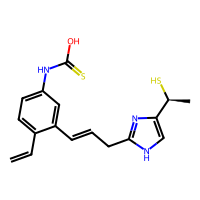
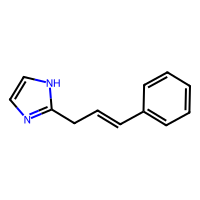
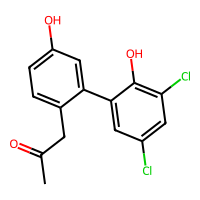
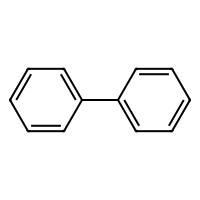
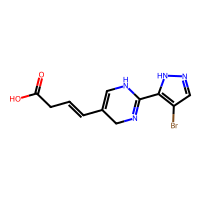
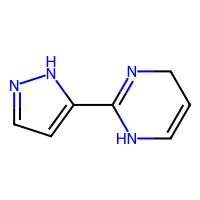
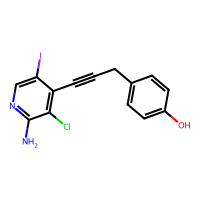
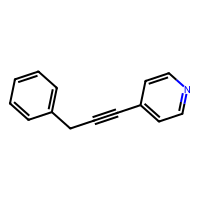
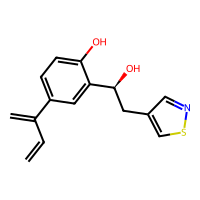
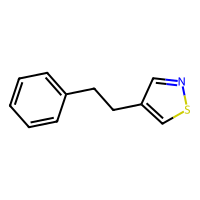
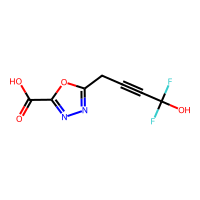
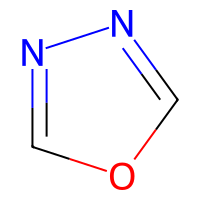
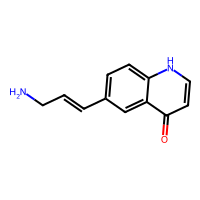
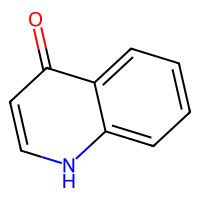
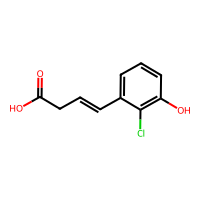
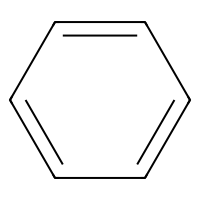
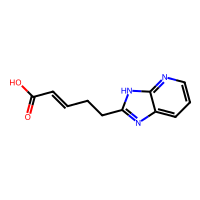
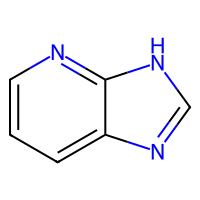
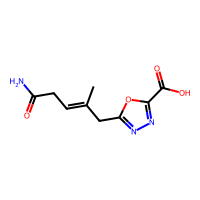
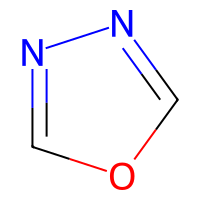

In [ ]:
# Generate RDKit molecule objects from curated SMILES, compute Bemis-Murcko scaffolds, and create corresponding molecule representations for both full structures and scaffolds within the DataFrame
PandasTools.AddMoleculeColumnToFrame(DB_denovo, smilesCol="SMILES_curated", molCol='MOL')
PandasTools.AddMurckoToFrame(DB_denovo, molCol='MOL', MurckoCol='SCAFFOLD')
PandasTools.AddMoleculeColumnToFrame(DB_denovo, smilesCol="SCAFFOLD",molCol='SCA_MOL')
DB_denovo

In [ ]:
# Save dataframe scaffolds
DB_denovo.to_csv("/content/drive/MyDrive/FBDD_Denovo_VRC/Caracterizacion_denovo/Scaffolds/Scaffolds_alldenovo.csv", sep=",", index=False)


In [ ]:
# Copy dataframe
CompoundsDB_denovo= DB_denovo.copy()

In [ ]:
# Group data by scaffold and count them
amount = CompoundsDB_denovo.groupby(['SCAFFOLD']).size()
print(f"Dataset with {amount.shape[0]} different entries:",amount.sort_values(ascending=False))

#New dataframe containing SMILES sequences for scaffolds and their counts, sorted from highest to lowest
df_sca_all = pd.DataFrame (amount, columns = ['Counts'] )
df_sca_all=df_sca_all.sort_values(by='Counts', ascending= False)
df_sca_all=df_sca_all.reset_index(level=None, drop=False)
print ('All:', df_sca_all.shape, df_sca_all.columns)
df_sca_all


Dataset with 225 different entries: SCAFFOLD
c1ccccc1                              179
C=C1Cc2ccccc2N1                        66
C1=CN(c2ccccc2)CNC1                    21
C1=CNC=NC1                             18
c1ccc2[nH]ncc2c1                       12
                                     ... 
c1nc(-c2csnn2)c[nH]1                    1
c1nnc(CCc2nn[nH]n2)[nH]1                1
c1nnc(CCc2cscn2)[nH]1                   1
c1ncc(Cc2nncs2)[nH]1                    1
c1ncc(CC[C@@H]2NCc3cc[nH]c32)[nH]1      1
Length: 225, dtype: int64
All: (225, 2) Index(['SCAFFOLD', 'Counts'], dtype='object')


,SCAFFOLD,Counts
0,c1ccccc1,179
1,C=C1Cc2ccccc2N1,66
2,C1=CN(c2ccccc2)CNC1,21
3,C1=CNC=NC1,18
4,c1ccc2[nH]ncc2c1,12
...,...,...
220,c1nc(-c2csnn2)c[nH]1,1
221,c1nnc(CCc2nn[nH]n2)[nH]1,1
222,c1nnc(CCc2cscn2)[nH]1,1
223,c1ncc(Cc2nncs2)[nH]1,1


In [ ]:
# Merge scaffold frequency data with the de novo compounds database using the 'SCAFFOLD' column (right join to retain all compounds), then calculate the percentage proportion of each scaffold based on total counts

df_scaf = pd.merge( df_sca_all, CompoundsDB_denovo, on='SCAFFOLD',how='right')
df_sca_all["Proportion"] = round(100 * df_sca_all["Counts"] / df_sca_all["Counts"].sum(), 2)

df_sca_all


,SCAFFOLD,Counts,Proportion
0,c1ccccc1,179,28.82
1,C=C1Cc2ccccc2N1,66,10.63
2,C1=CN(c2ccccc2)CNC1,21,3.38
3,C1=CNC=NC1,18,2.90
4,c1ccc2[nH]ncc2c1,12,1.93
...,...,...,...
220,c1nc(-c2csnn2)c[nH]1,1,0.16
221,c1nnc(CCc2nn[nH]n2)[nH]1,1,0.16
222,c1nnc(CCc2cscn2)[nH]1,1,0.16
223,c1ncc(Cc2nncs2)[nH]1,1,0.16


In [ ]:
# Save df
df_scaf.to_csv("/content/drive/MyDrive/FBDD_Denovo_VRC/Caracterizacion_denovo/Scaffolds/Scaffolds_count_denovo.csv", sep=",", index=False)


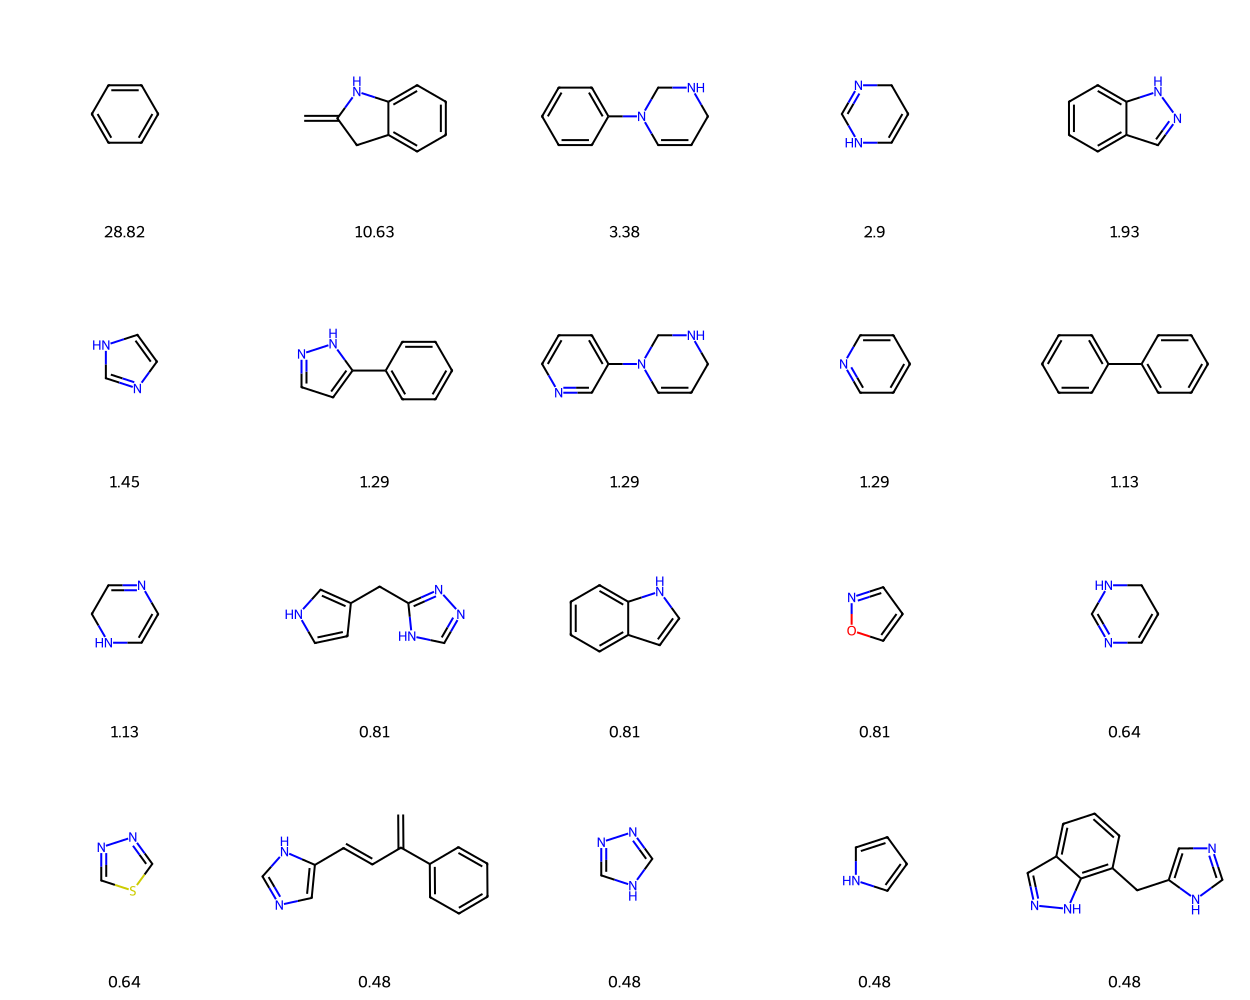

In [ ]:
# Select the top 20 scaffolds, convert their SMILES into RDKit molecule objects, and visualize them in a grid image
mol = [Chem.MolFromSmiles(x) for x in df_sca_all["SCAFFOLD"]][:20]
leyendas = [str(x) for x in df_sca_all["Proportion"].tolist()][:20]

mols_scaffolds = Chem.Draw.MolsToGridImage(
    mol,
    legends=leyendas,
    molsPerRow=5,
    subImgSize=(250,250),
    returnPNG=False
)

mols_scaffolds.save("/content/drive/MyDrive/FBDD_Denovo_VRC/Caracterizacion_denovo/Scaffolds/scaffolds_20.png")
mols_scaffolds